<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Churn_Aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importação de Bibliotecas**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,O,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,O,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,O,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,O,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,O,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7040,4801-JZAZL,Female,O,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,O,No,No,66.0,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No
7043,9763-GRSKD,Male,O,Yes,Yes,13.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
7044,6865-JZNKO,Female,O,No,No,30.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.30,1530.6,No


# I. Análise Exploriatória Geral

1. Quantas linhas e colunas tem o dataset?
2. Qual a porcentagem de nulos?
3. Qual o tipo de cada coluna?
4. Existem colunas que podemos remover?
5. Os tipos de coluna estão adequados para os tipos de variáveis?
6. Temos dados duplicados?
7. Qual a média, desvio padrão e amplitude das colunas numéricas?

###1. Quantas linhas e colunas tem o dataset?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7045 non-null   object 
 1   gender            7045 non-null   object 
 2   SeniorCitizen     7045 non-null   object 
 3   Partner           7045 non-null   object 
 4   Dependents        7045 non-null   object 
 5   tenure            6693 non-null   float64
 6   PhoneService      7045 non-null   object 
 7   MultipleLines     7045 non-null   object 
 8   InternetService   7045 non-null   object 
 9   OnlineSecurity    7045 non-null   object 
 10  OnlineBackup      7045 non-null   object 
 11  DeviceProtection  7045 non-null   object 
 12  TechSupport       7045 non-null   object 
 13  StreamingTV       7045 non-null   object 
 14  StreamingMovies   7045 non-null   object 
 15  Contract          7045 non-null   object 
 16  PaperlessBilling  7045 non-null   object 


In [7]:
print(f'O dataset tem {df.shape[0]} linhas')
print(f'O dataset tem {df.shape[1]} colunas')

O dataset tem 7045 linhas
O dataset tem 21 colunas


###2. Qual a porcentagem de nulos?

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,352
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df_nulos = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)*100
df_nulos

,0
tenure,4.996451
gender,0.000000
SeniorCitizen,0.000000
Partner,0.000000
customerID,0.000000
Dependents,0.000000
PhoneService,0.000000
MultipleLines,0.000000
InternetService,0.000000
OnlineSecurity,0.000000


### 3. Qual o tipo de cada coluna?

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7045 non-null   object 
 1   gender            7045 non-null   object 
 2   SeniorCitizen     7045 non-null   object 
 3   Partner           7045 non-null   object 
 4   Dependents        7045 non-null   object 
 5   tenure            6693 non-null   float64
 6   PhoneService      7045 non-null   object 
 7   MultipleLines     7045 non-null   object 
 8   InternetService   7045 non-null   object 
 9   OnlineSecurity    7045 non-null   object 
 10  OnlineBackup      7045 non-null   object 
 11  DeviceProtection  7045 non-null   object 
 12  TechSupport       7045 non-null   object 
 13  StreamingTV       7045 non-null   object 
 14  StreamingMovies   7045 non-null   object 
 15  Contract          7045 non-null   object 
 16  PaperlessBilling  7045 non-null   object 


### 4. Existem colunas que podemos remover?

In [12]:
df = df.drop('customerID', axis=1)

In [13]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,O,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,O,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,O,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,O,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,O,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7040,Female,O,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,Male,O,No,No,66.0,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No
7043,Male,O,Yes,Yes,13.0,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No


### 5. Os tipos de coluna estão adequados para os tipos de variáveis?

In [20]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3877
Two year,1695
One year,1473


In [21]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1613
Bank transfer (automatic),1545
Credit card (automatic),1522


In [22]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace('O', 0)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Alteramos os valores de "O" para 0 mas precisamos alterar o tipo da coluna

In [24]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7045 non-null   object 
 1   SeniorCitizen     7045 non-null   int64  
 2   Partner           7045 non-null   object 
 3   Dependents        7045 non-null   object 
 4   tenure            6693 non-null   float64
 5   PhoneService      7045 non-null   object 
 6   MultipleLines     7045 non-null   object 
 7   InternetService   7045 non-null   object 
 8   OnlineSecurity    7045 non-null   object 
 9   OnlineBackup      7045 non-null   object 
 10  DeviceProtection  7045 non-null   object 
 11  TechSupport       7045 non-null   object 
 12  StreamingTV       7045 non-null   object 
 13  StreamingMovies   7045 non-null   object 
 14  Contract          7045 non-null   object 
 15  PaperlessBilling  7045 non-null   object 
 16  PaymentMethod     7045 non-null   object 


## 6. Temos dados duplicados?

In [27]:
df.duplicated().sum()

np.int64(22)

In [29]:
duplicados = df[df.duplicated(keep=False)]
duplicados

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
10,Male,0,Yes,Yes,13.0,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
22,Male,0,No,No,1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
25,Female,0,No,No,30.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.30,1530.6,No
100,Male,0,No,No,1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
542,Female,0,No,No,1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1.0,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
662,Male,0,No,No,1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
690,Male,0,No,No,1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
964,Male,0,No,No,1.0,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
976,Male,0,No,No,1.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,Yes


In [30]:
df_sem_duplicados = df.drop_duplicates()

In [32]:
df_sem_duplicados.duplicated().sum()

np.int64(0)

In [33]:
df = df_sem_duplicados

### 7. Qual a média, desvio padrão e amplitude das colunas numéricas?

In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7023.000000,6671.000000,7023.000000
mean,0.162466,32.377155,64.839193
std,0.368904,24.544556,30.074138
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.675000
50%,0.000000,29.000000,70.400000
75%,0.000000,55.500000,89.900000
max,1.000000,72.000000,118.750000


#II. Análise Univariada

<Axes: >

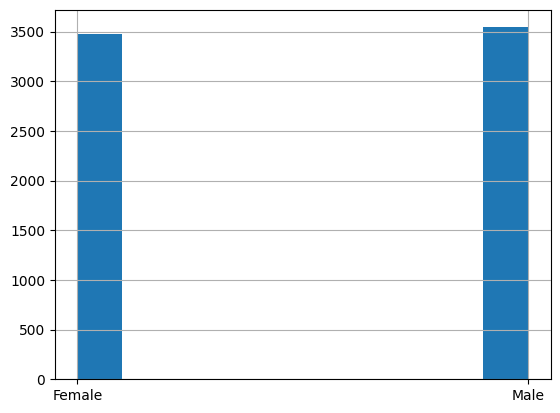

In [35]:
df['gender'].hist()

<Axes: >

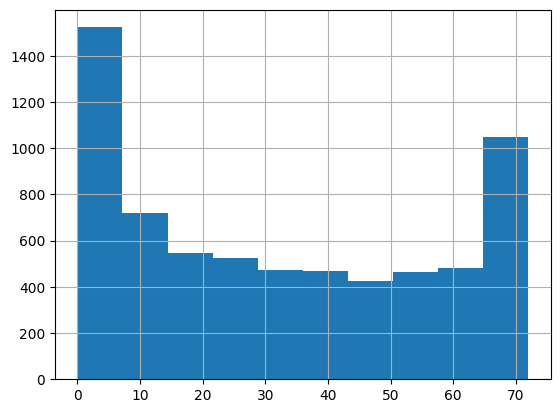

In [44]:
df['tenure'].hist()

<Axes: >

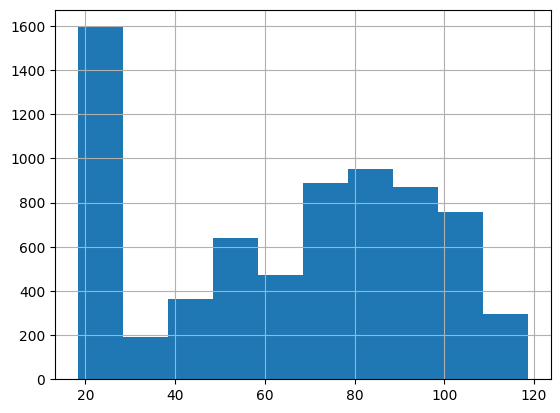

In [45]:
df['MonthlyCharges'].hist()

<Axes: >

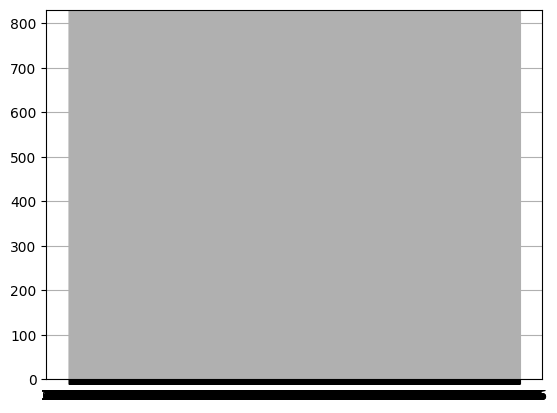

In [46]:
df['TotalCharges'].hist()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7023 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7023 non-null   object 
 1   SeniorCitizen     7023 non-null   int64  
 2   Partner           7023 non-null   object 
 3   Dependents        7023 non-null   object 
 4   tenure            6671 non-null   float64
 5   PhoneService      7023 non-null   object 
 6   MultipleLines     7023 non-null   object 
 7   InternetService   7023 non-null   object 
 8   OnlineSecurity    7023 non-null   object 
 9   OnlineBackup      7023 non-null   object 
 10  DeviceProtection  7023 non-null   object 
 11  TechSupport       7023 non-null   object 
 12  StreamingTV       7023 non-null   object 
 13  StreamingMovies   7023 non-null   object 
 14  Contract          7023 non-null   object 
 15  PaperlessBilling  7023 non-null   object 
 16  PaymentMethod     7023 non-null   object 
 17  

<Axes: >

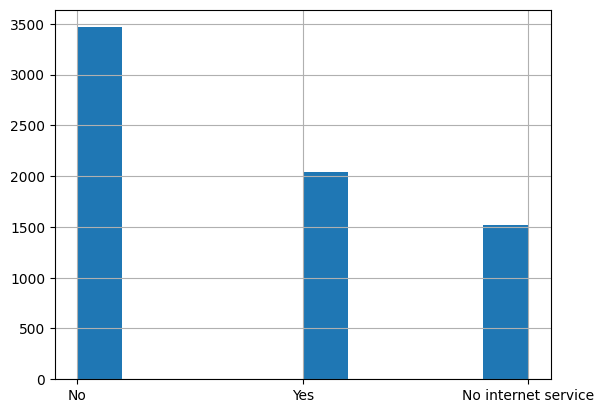

In [47]:
df['TechSupport'].hist()

In [48]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

<Axes: >

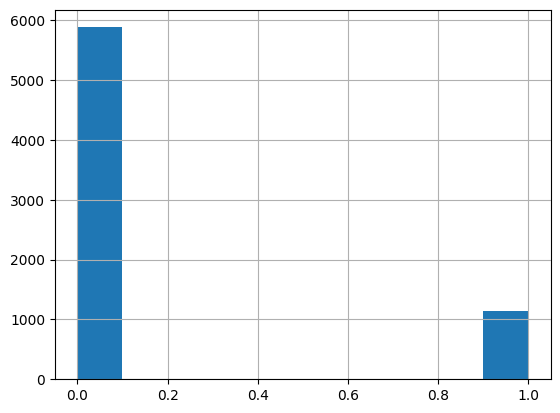

In [49]:
df['SeniorCitizen'].hist()

In [51]:
df_idosos = df['SeniorCitizen'].value_counts(normalize=True)

<Axes: xlabel='SeniorCitizen', ylabel='proportion'>

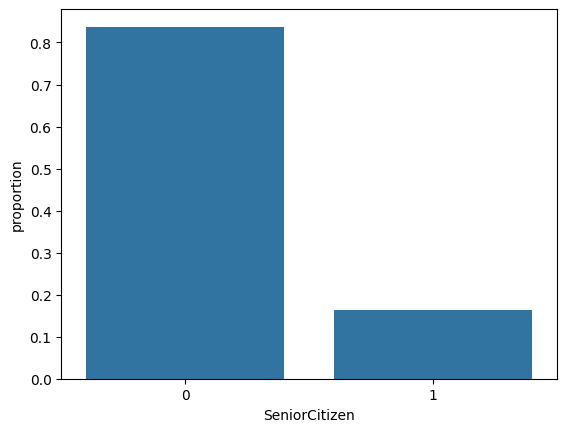

In [52]:
sns.barplot(data=df_idosos)

In [55]:
df['PaymentMethod'].value_counts(normalize=True)

,proportion
PaymentMethod,
Electronic check,0.335896
Mailed check,0.227538
Bank transfer (automatic),0.219849
Credit card (automatic),0.216717


In [53]:
df_metodos_pay = df['PaymentMethod'].value_counts(normalize=True)

<Axes: xlabel='PaymentMethod', ylabel='proportion'>

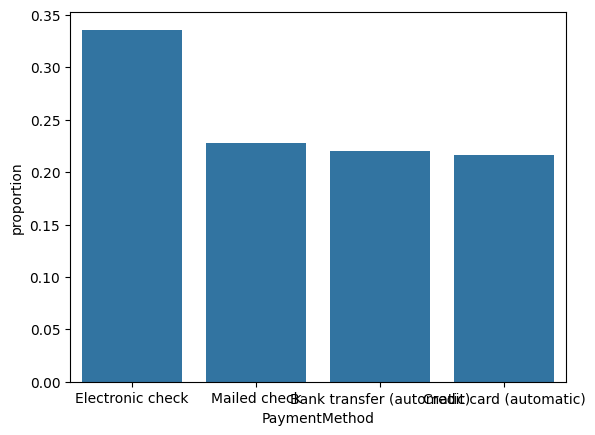

In [54]:
sns.barplot(data=df_metodos_pay)

In [56]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.735583
Yes,0.264417


In [57]:
df_churn = df['Churn'].value_counts(normalize=True)

<Axes: xlabel='Churn', ylabel='proportion'>

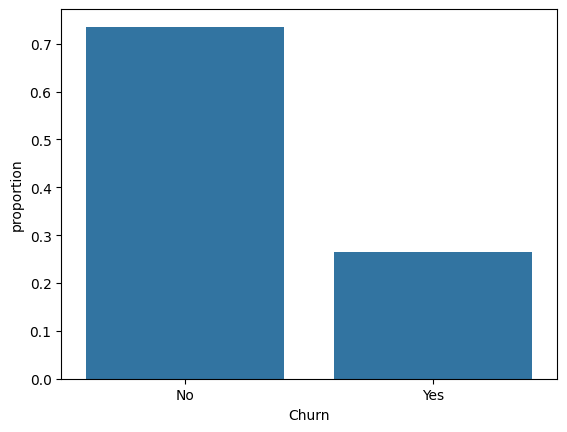

In [58]:
sns.barplot(data=df_churn)

# III. Tratamento da Coluna Total Charges

In [59]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
,11
19.75,9
20.2,8
19.9,7
20.05,7
...,...
130.15,1
3211.9,1
7843.55,1


In [60]:
df['tenure'].value_counts()

,count
tenure,
1.0,565
72.0,340
2.0,226
3.0,194
4.0,169
...,...
45.0,53
39.0,51
36.0,50


In [71]:
(df['TotalCharges'] == ' ').sum()

np.int64(0)

In [66]:
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0.0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0.0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0.0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0.0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [67]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

/tmp/ipykernel_635/2744223278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


<Axes: >

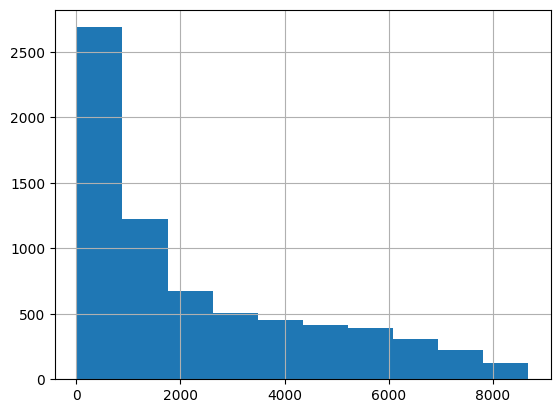

In [69]:
df['TotalCharges'].hist()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7023 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7023 non-null   object 
 1   SeniorCitizen     7023 non-null   int64  
 2   Partner           7023 non-null   object 
 3   Dependents        7023 non-null   object 
 4   tenure            6671 non-null   float64
 5   PhoneService      7023 non-null   object 
 6   MultipleLines     7023 non-null   object 
 7   InternetService   7023 non-null   object 
 8   OnlineSecurity    7023 non-null   object 
 9   OnlineBackup      7023 non-null   object 
 10  DeviceProtection  7023 non-null   object 
 11  TechSupport       7023 non-null   object 
 12  StreamingTV       7023 non-null   object 
 13  StreamingMovies   7023 non-null   object 
 14  Contract          7023 non-null   object 
 15  PaperlessBilling  7023 non-null   object 
 16  PaymentMethod     7023 non-null   object 
 17  

### IV. Análise Bivariada

* Clientes mais idosos tendem a cancelar mais o serviço?
* Existe diferença na taxa de cancelamento entre homens e mulheres?
* Clientes que possuem parceiro(a) cancelam menos?
* Clientes com dependentes tendem a permanecer mais tempo na empresa?
* Clientes mais antigos cancelam menos?
* Em quais faixas de tempo de permanência ocorre a maior taxa de churn?
* Clientes recém-adquiridos apresentam maior risco de cancelamento?
* O tipo de contrato influencia o cancelamento?
* Existe alguma faixa de cobrança mensal onde o churn é mais frequente?
* O tipo de internet influencia o cancelamento?

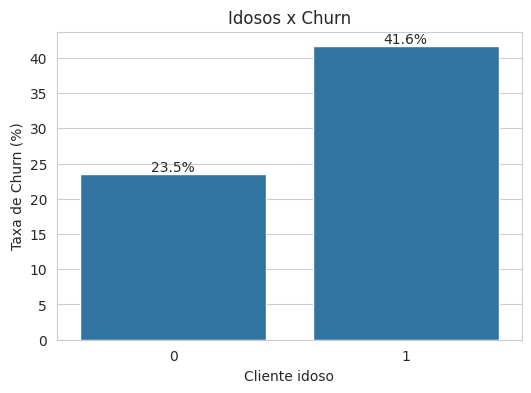

In [72]:
sns.set_style("whitegrid")

# agrupar a variável SeniorCitizen com Churn
taxa_senior = (
    df.groupby('SeniorCitizen')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='Taxa_Churn')
)

# plotar o gráfico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=taxa_senior,
    x='SeniorCitizen',
    y='Taxa_Churn'
)

# adicionar o percentual sobre cada barra
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%',
                (barra.get_x() + barra.get_width()/2, altura),
                ha='center',
                va='bottom')

plt.title('Idosos x Churn')
plt.xlabel('Cliente idoso')
plt.ylabel('Taxa de Churn (%)')

plt.show()

### Existe diferença na taxa de cancelamento entre homens e mulheres?

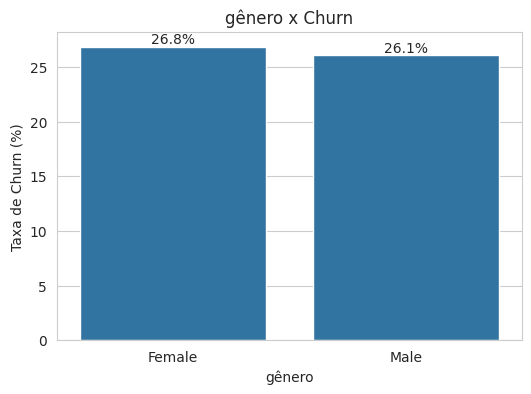

In [75]:
sns.set_style("whitegrid")

# agrupar a variável SeniorCitizen com Churn
taxa_senior = (
    df.groupby('gender')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='Taxa_Churn')
)

# plotar o gráfico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=taxa_senior,
    x='gender',
    y='Taxa_Churn'
)

# adicionar o percentual sobre cada barra
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%',
                (barra.get_x() + barra.get_width()/2, altura),
                ha='center',
                va='bottom')

plt.title('gênero x Churn')
plt.xlabel('gênero')
plt.ylabel('Taxa de Churn (%)')

plt.show()

### Clientes que possuem parceiro(a) cancelam menos?

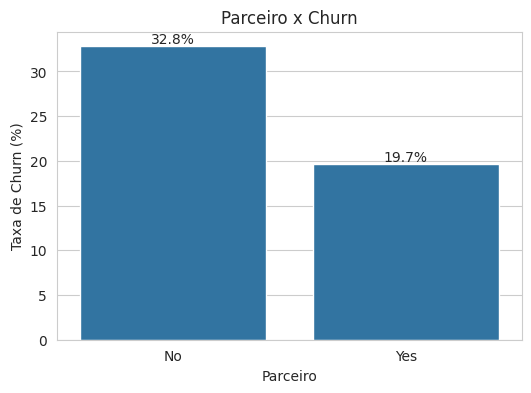

In [77]:
sns.set_style("whitegrid")

# agrupar a variável SeniorCitizen com Churn
taxa_senior = (
    df.groupby('Partner')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='Taxa_Churn')
)

# plotar o gráfico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=taxa_senior,
    x='Partner',
    y='Taxa_Churn'
)

# adicionar o percentual sobre cada barra
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%',
                (barra.get_x() + barra.get_width()/2, altura),
                ha='center',
                va='bottom')

plt.title('Parceiro x Churn')
plt.xlabel('Parceiro')
plt.ylabel('Taxa de Churn (%)')

plt.show()

# V. Pré-Processamento de Dados

In [82]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,352
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [83]:
df = df.dropna(subset=['TotalCharges'])

In [81]:
df['tenure'].value_counts()

,count
tenure,
1.0,565
72.0,340
2.0,226
3.0,194
4.0,169
...,...
45.0,53
39.0,51
36.0,50


In [85]:
df['tenure'] = df['tenure'].fillna(df['tenure'].median())

/tmp/ipykernel_635/1858606991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tenure'] = df['tenure'].fillna(df['tenure'].median())


### Como temos 352 nulos em Tenure que é o tempo do contrato da pessoa, decidimos realizar a mediana para completar os dados e como temos apenas 11 de total charges excluimos por ser um valor irrisório.

In [87]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7012 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7012 non-null   object 
 1   SeniorCitizen     7012 non-null   int64  
 2   Partner           7012 non-null   object 
 3   Dependents        7012 non-null   object 
 4   tenure            7012 non-null   float64
 5   PhoneService      7012 non-null   object 
 6   MultipleLines     7012 non-null   object 
 7   InternetService   7012 non-null   object 
 8   OnlineSecurity    7012 non-null   object 
 9   OnlineBackup      7012 non-null   object 
 10  DeviceProtection  7012 non-null   object 
 11  TechSupport       7012 non-null   object 
 12  StreamingTV       7012 non-null   object 
 13  StreamingMovies   7012 non-null   object 
 14  Contract          7012 non-null   object 
 15  PaperlessBilling  7012 non-null   object 
 16  PaymentMethod     7012 non-null   object 
 17  

### Tempo de permanência em categorias - Dividimos o tenure (tempo de contrato) em 4 grupos, 0-1, 1-2, 2-4, 4-6. Para ajudar o modelo

In [89]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 ano','1-2 anos','2-4 anos','4-6 anos']
)

/tmp/ipykernel_635/2127354869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tenure_group'] = pd.cut(


In [90]:
df['tenure_group'].value_counts()

,count
tenure_group,
4-6 anos,2124
0-1 ano,2056
2-4 anos,1858
1-2 anos,974


In [91]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 ano
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 anos
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 ano
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 anos
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 ano


Utilizamos a coluna tenure_group e aplicamos o One-Hot Encoder porque ela possui poucas categorias. Assim, cada categoria é transformada em uma coluna com valores 0 e 1, permitindo que o modelo trabalhe com essas informações.

In [93]:
df = pd.get_dummies(
    df,
    columns=['tenure_group'],
    dtype=int
)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7012 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 7012 non-null   object 
 1   SeniorCitizen          7012 non-null   int64  
 2   Partner                7012 non-null   object 
 3   Dependents             7012 non-null   object 
 4   tenure                 7012 non-null   float64
 5   PhoneService           7012 non-null   object 
 6   MultipleLines          7012 non-null   object 
 7   InternetService        7012 non-null   object 
 8   OnlineSecurity         7012 non-null   object 
 9   OnlineBackup           7012 non-null   object 
 10  DeviceProtection       7012 non-null   object 
 11  TechSupport            7012 non-null   object 
 12  StreamingTV            7012 non-null   object 
 13  StreamingMovies        7012 non-null   object 
 14  Contract               7012 non-null   object 
 15  Paperless

Enconding para Partner

In [96]:
df['Partner'] = df['Partner'].map({
    'No': 0,
    'Yes': 1
})

Enconding para o Target Churn

In [97]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

Enconding para o Contract

In [98]:
df = pd.get_dummies(
    df,
    columns=['Contract'],
    drop_first=True,
    dtype=int
)

Enconding para o PaymentMethod

In [99]:
df = pd.get_dummies(
    df,
    columns=['PaymentMethod'],
    drop_first=True,
    dtype=int
)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7012 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7012 non-null   object 
 1   SeniorCitizen                          7012 non-null   int64  
 2   Partner                                7012 non-null   int64  
 3   Dependents                             7012 non-null   object 
 4   tenure                                 7012 non-null   float64
 5   PhoneService                           7012 non-null   object 
 6   MultipleLines                          7012 non-null   object 
 7   InternetService                        7012 non-null   object 
 8   OnlineSecurity                         7012 non-null   object 
 9   OnlineBackup                           7012 non-null   object 
 10  DeviceProtection                       7012 non-null   object 
 11  TechSuppo

In [102]:
X = df[
    [
        'SeniorCitizen',
        'Partner',
        'MonthlyCharges',
        'TotalCharges',
        'tenure_group_0-1 ano',
        'tenure_group_1-2 anos',
        'tenure_group_2-4 anos',
        'tenure_group_4-6 anos',
        'Contract_One year',
        'Contract_Two year',
        'PaymentMethod_Credit card (automatic)',
        'PaymentMethod_Electronic check',
        'PaymentMethod_Mailed check'
    ]
]

y = df['Churn']

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [104]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5609, 13)
(1403, 13)
(5609,)
(1403,)


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_numericas = [
    'MonthlyCharges',
    'TotalCharges'
]

X_train[colunas_numericas] = scaler.fit_transform(
    X_train[colunas_numericas]
)

X_test[colunas_numericas] = scaler.transform(
    X_test[colunas_numericas]
)